In [1]:
import os
from time import time
from numpy.random import random

from sklearn.cluster import KMeans
import geopandas as gpd
from shapely.geometry import Point

from gridworkbench.containers import Bus, Node
from gridworkbench.devices import Load
from gridworkbench.utils import geograph

from sgb_suite.syntheticgridbuilder import SyntheticGridBuilder
from sgb_suite.sub_planning import LoadFragment
from sgb_suite.sub_planning import GenFragment, GenUnit
import pandas as pd
import numpy as np
from esa import SAW

from large_load_allocation import run_large_load_allocation, LARGE_LOAD_MW

tlap = time()
def lap(txt): global tlap; print(txt + f" | {time()-tlap} secs"); tlap = time()

# Cell 2: Initialize Synthetic Grid Builder

Creates an `SyntheticGridBuilder` instance from `texas_config.txt`.

The config file sets:
- `root` — base path for the SGB framework (used internally)
- `output_code` — subfolder name for outputs (overridden later in the paths cell)
- Various cost parameters for transmission planning

> **Note:** The `sgb.output_folder` is overridden in the next code cell to point to `Texas_Synthetic_Grid/Output/`.

# Cell 1: Imports

Loads all required Python packages for the ERCOT synthetic grid builder pipeline:

| Package | Purpose |
|---------|---------|
| `sklearn.cluster.KMeans` | Substation and EHV clustering |
| `geopandas` / `shapely` | Spatial operations (weather zones, counties, ERCOT boundary) |
| `gridworkbench` | Core synthetic grid data structures (`Bus`, `Node`, `Load`) |
| `sgb_suite` | Synthetic Grid Builder framework (`SyntheticGridBuilder`, `LoadFragment`, `GenFragment`) |
| `pandas` / `numpy` | Data loading and numerical operations |
| `esa.SAW` | PowerWorld SimAuto interface for reading reference cases |
| `large_load_allocation` | Custom module for Thomas Cluster Process large load placement |

# ERCOT Texas Synthetic Grid — Substation Planning Notebook

---

## TODO List

### Tuning Parameters (Ask Dr. B)
- [ ] **`cluster_load_frags(N)`** — what value of `N` for Texas? Currently `18000` (placeholder). Controls number of substations created.
- [ ] **`nc` for EHV KMeans** — currently `60`. EI used `400`; Texas is ~1/8 scale. What is the right number of EHV substations?
- [ ] **`region_load_factor`** per weather zone — currently uniform `1.0`. Need zone-specific scaling factors from Dr. B.
- [ ] **Load scaling divisor** `/2.1` — is this the right factor? Converts raw census population estimate to system-level MW.
- [ ] **Large load MW threshold** — currently `>= 75 MW` (ERCOT design criterion). Confirm with Dr. B.

### Bus Count Target (~10,000 buses)
- [ ] Current output is ~6,870 substations, but each substation can have multiple buses (one per kV level). Need to verify total bus count and tune `cluster_load_frags(N)` and EHV `nc` to reach ~10,000 buses.
- [ ] Consider: fewer people per cluster (lower `N`) = more substations = more buses. Also more EHV substations = more multi-bus subs.

### Large Load Substation Assignment
- [ ] Currently large loads are attached to the **nearest existing substation**. Instead, each large load should get its **own dedicated substation** — create a new `Sub` at the large load's lat/lon, then connect it to the nearest existing substation via a short branch.
- [ ] Decide kV level for dedicated large-load substations (base kV of the zone? or EHV?).

### Bus and Substation Naming Convention
- [ ] Current naming: `"CountyName-TX-TractNumber_kV"` (e.g., `"Harris-TX-1234_115"`). Decide if this is the final format.
- [ ] Options to consider: sequential numbering, ERCOT-style naming, region prefix, or PowerWorld-friendly format.
- [ ] Names must be unique and fit PowerWorld's field length limits.

### Validation and Design Metrics
- [ ] Add per-weather-zone summary table: total MW (load vs gen), number of subs, number of buses, kV breakdown.
- [ ] Compare synthetic grid statistics against Texas2k reference case (sub count per zone, load distribution, gen mix).
- [ ] Validate transmission-level metrics once lines are added (N-1, voltage profile, power flow convergence).
- [ ] Large load validation plot already implemented (Ripley's L, NN CDF, spatial map) — review results with Dr. B.

### Planned / Queued Generation (ERCOT GIS Report)
- [ ] `eia860_2022_gens_planned` is loaded (1,865 large + 66 small) but **not yet integrated** into generator fragments.
- [ ] GIS Report headers are at **row 30** — fix `header=0` to `header=30` in the read cell.
- [ ] Column mapping needed: `Capacity (MW)` -> pmax, `Fuel` / `Technology` -> fuel type, `Project Name` -> name, `County` -> zone, `CDR Reporting Zone` -> area.
- [ ] `POI Location` is a text field (substation name), not lat/lon — need geocoding via county centroid or reference case substation match.
- [ ] Decide: include all planned gens, or only those with `IA Signed` date?

```python
# Example code to integrate GIS planned generators:
gis_large = pd.read_excel(_gis_file, sheet_name='Project Details - Large Gen', header=30)
gis_small = pd.read_excel(_gis_file, sheet_name='Project Details - Small Gen', header=30)  # find correct header row
gis_df = pd.concat([gis_large, gis_small], ignore_index=True)

# Filter to projects with signed IA (committed)
# gis_df = gis_df[gis_df['IA Signed'].notna()]

# Get county centroids for lat/lon (since POI Location is text)
county_centroids = county_gdf.set_index(
    county_gdf['US_Count_1'].str.replace(' County', '').str.strip()
)[['geometry']].copy()
county_centroids['lat'] = county_centroids.geometry.centroid.y
county_centroids['lon'] = county_centroids.geometry.centroid.x

for _, row in gis_df.iterrows():
    mw = _val(row.get('Capacity (MW)', 0))
    if mw <= 5: continue
    county = _str(row.get('County', ''))
    if county not in county_centroids.index: continue

    lat = county_centroids.loc[county, 'lat']
    lon = county_centroids.loc[county, 'lon']
    if not is_inside_ercot(lat, lon): continue

    gf = GenFragment(
        name=_str(row.get('Project Name', 'GIS_Project')),
        lat=lat, lon=lon,
        plant_code=_str(row.get('INR', '')),
        area=assign_weather_zone(lat, lon),
        units=[]
    )
    if gf.area is None: continue
    gf.zone = county

    fuel = _str(row.get('Fuel', ''))
    tech = _str(row.get('Technology', ''))
    gu = GenUnit(fueltype=tech if tech else fuel, pmax=mw, pmin=0,
                 unit_id=_str(row.get('INR', '')))
    gf.units.append(gu)
    sgb.gen_frags.append(gf)
```

### Code Cleanup
- [ ] Remove diagnostic print statements from `extract_reference_large_loads()` in `large_load_allocation.py` (Steps 1–5 prints).
- [ ] Investigate `LoadMW` vs `LoadSMW` in large load extraction — which field to use? (marked TODO in code).
- [ ] Add error handling for missing shapefiles / input files (currently fails silently or with cryptic errors).

### Future Steps (After Substation Planning)
- [ ] Transmission line routing (next notebook / pipeline stage)
- [ ] Reactive power planning
- [ ] Dynamic model assignment
- [ ] Case validation in PowerWorld (power flow solve, contingency analysis)

---

In [2]:
sgb = SyntheticGridBuilder("texas_config.txt")



********* STARTING UP SYNTHETIC GRID BUILDER 2026-03-10 17:21:59.221217 *********


# ⚙️ Configuration — Read Before Running

This notebook uses **relative paths** automatically derived from its own location.
No hardcoded paths need to be changed as long as you follow the folder structure below.

## Expected Folder Structure

```
Texas_Synthetic_Grid/
├── Creation/          ← this notebook lives here
│   ├── sub_planning.ipynb
│   └── texas_config.txt
├── Inputs/            ← all input files go here (see sections below)
│   ├── 2025_Gaz_tracts_national.csv
│   ├── DECENNIALDP2020.DP1-Data.csv
│   ├── 2___Plant_Y2024.xlsx
│   ├── 3_1_Generator_Y2024.xlsx
│   ├── RPT.*.GIS_Report_January2026.xlsx
│   ├── ERCOT_WEATHER_ZONE_modified.shp  (+ .dbf, .prj, .shx, etc.)
│   ├── Texas_Counties.shp               (+ .dbf, .prj, .shx, etc.)
│   └── ne_10m_coastline/ne_10m_coastline.shp
└── Output/            ← created automatically; output files saved here
    └── ERCOT_Subs.aux
```

## What You May Need to Update

| Item | Where | Notes |
|------|--------|-------|
| **Gazetteer file** | `Inputs/` | Download latest from Census Bureau (see cell below) |
| **DP1 population** | `Inputs/` | Download Texas tracts from data.census.gov (see cell below) |
| **EIA 860 Plant/Generator** | `Inputs/` | Download latest year from eia.gov/electricity/data/eia860 |
| **ERCOT GIS Report** | `Inputs/` | Download latest from ERCOT GIS queue report; update filename in read cell |
| **PowerWorld reference case** | hardcoded path in kV config cell | Update `REFERENCE_CASE` path to your local `.pwb` file |

## Output
`ERCOT_Subs.aux` is saved to `Texas_Synthetic_Grid/Output/` automatically.

# Geography data source
These are both U.S. Census Bureau datasets. Here's where to get updated versions:

1. Gazetteer Files (Census Tract geographic data)

The latest is the 2024 Gazetteer file:

Go to: https://www.census.gov/geographies/reference-files/time-series/geo/gazetteer-files.html
Download the Census Tracts file
It contains lat/long, land area, and water area for each tract

# Population data 
1.  Go to https://data.census.gov
2.  In the search bar, type DP1 and hit Enter
3.  Select DECENNIALDP2020.DP1 - Profile of General Population and Housing Characteristics
4.  Click Geographies filter:
5.  Select Census Tract
6.  Select Texas
7.   Click All Census Tracts within Texas
8.  Click Download (table icon) → Download as Zip file
This gives you the same format as the DECENNIALDP2020.DP1-Data.csv file your code expects.

#   EIA 860 data 
This is EIA Form 860 data — the Electric Generator Inventory from the U.S. Energy Information Administration.

To get the latest version:

Go to https://www.eia.gov/electricity/data/eia860/
Under Early Release or Final Release, download the most recent year (2024 or 2023)
Extract the ZIP file — look for the file 3_1_Generator_YXXXX.csv (the generator data)

In [3]:
PROJECT_DIR = os.getcwd()
FOLDER_DIR = os.path.dirname(PROJECT_DIR)
INPUT_DIR = os.path.join(FOLDER_DIR, "Inputs")
OUTPUT_DIR = os.path.join(FOLDER_DIR, "Output")

sgb.input_folder = INPUT_DIR
sgb.output_folder = OUTPUT_DIR
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Input  folder: {INPUT_DIR}")
print(f"Output folder: {OUTPUT_DIR}")

Input  folder: d:\Project\OneDrive - Texas A&M University\Desktop\Research Project\Synthetic_Creationg\Texas_Synthetic_Grid\Inputs
Output folder: d:\Project\OneDrive - Texas A&M University\Desktop\Research Project\Synthetic_Creationg\Texas_Synthetic_Grid\Output


# Cell 3: Set Input/Output Paths

Derives all paths relative to the notebook's location — no hardcoded paths needed.

```
Texas_Synthetic_Grid/
├── Creation/    ← PROJECT_DIR (os.getcwd())
├── Inputs/      ← INPUT_DIR (all data files)
└── Output/      ← OUTPUT_DIR (created automatically)
```

Overrides both `sgb.input_folder` and `sgb.output_folder` so that all file I/O uses the project structure instead of the config file's `root` path.

In [4]:
# ── Read Input Files with Pandas ─────────────────────────────────────────────

# Gazetteer: national census tracts — filter to TX, match by GEOID
census2020_geo_df = pd.read_csv(
    os.path.join(sgb.input_folder, "2025_Gaz_tracts_national.csv"),
    dtype={'GEOID': str, 'USPS': str}
)
census2020_geo_df = census2020_geo_df[census2020_geo_df['USPS'] == 'TX'].copy()
print(f"Gazetteer: {len(census2020_geo_df)} Texas census tracts")

# DP1 Population: Texas census tracts only (2nd row is human-readable labels — skip it)
census2020_pop_df = pd.read_csv(
    os.path.join(sgb.input_folder, "DECENNIALDP2020.DP1-Data.csv"),
    skiprows=[1], dtype={'GEO_ID': str}
)
# GEO_ID format: "1400000US48XXX..." → extract 11-digit GEOID
census2020_pop_df['GEOID'] = census2020_pop_df['GEO_ID'].str.replace('1400000US', '', regex=False)
census2020_pop_df = census2020_pop_df[census2020_pop_df['GEOID'].str.len() == 11].copy()
print(f"DP1: {len(census2020_pop_df)} Texas census tracts")

# Merge geo + pop on GEOID — single iterable with all needed columns
census_df = census2020_geo_df.merge(census2020_pop_df, on='GEOID', how='inner')
census_records = census_df.to_dict('records')
print(f"Merged: {len(census_records)} matched census tracts")

# EIA 860 Plant data — row 0 is title, row 1 is actual headers
eia860_2022_plants = pd.read_excel(
    os.path.join(sgb.input_folder, "2___Plant_Y2024.xlsx"),
    sheet_name='Plant', header=1
).to_dict('records')
print(f"EIA Plants: {len(eia860_2022_plants)} | columns sample: {list(pd.read_excel(os.path.join(sgb.input_folder, '2___Plant_Y2024.xlsx'), sheet_name='Plant', header=1, nrows=0).columns[:5])}")

# EIA 860 Generator data — row 0 is title, row 1 is actual headers
eia860_2022_gens_operable = pd.read_excel(
    os.path.join(sgb.input_folder, "3_1_Generator_Y2024.xlsx"),
    sheet_name='Operable', header=1
).to_dict('records')
print(f"EIA Operable Generators: {len(eia860_2022_gens_operable)} | columns sample: {list(pd.read_excel(os.path.join(sgb.input_folder, '3_1_Generator_Y2024.xlsx'), sheet_name='Operable', header=1, nrows=0).columns[:5])}")

# ERCOT GIS Report — Large Gen + Small Gen sheets (planned/queued generation)
_gis_file = os.path.join(sgb.input_folder, "RPT.00015933.0000000000000000.20260202.150301327.GIS_Report_January2026.xlsx")
_large = pd.read_excel(_gis_file, sheet_name='Project Details - Large Gen', header=0)
_small = pd.read_excel(_gis_file, sheet_name='Project Details - Small Gen', header=0)
eia860_2022_gens_planned = pd.concat([_large, _small], ignore_index=True)
print(f"ERCOT GIS planned generators: {len(eia860_2022_gens_planned)} ({len(_large)} large + {len(_small)} small)")

Gazetteer: 6896 Texas census tracts
DP1: 6897 Texas census tracts
Merged: 6896 matched census tracts
EIA Plants: 16132 | columns sample: ['Utility ID', 'Utility Name', 'Plant Code', 'Plant Name', 'Street Address']
EIA Operable Generators: 26856 | columns sample: ['Utility ID', 'Utility Name', 'Plant Code', 'Plant Name', 'State']
ERCOT GIS planned generators: 1931 (1865 large + 66 small)


# Cell 4: Read Input Files (Census, EIA, ERCOT GIS)

Loads all tabular input data using **pandas** (not `sgb.read_csv()`):

| File | Source | What it provides |
|------|--------|-----------------|
| `2025_Gaz_tracts_national.csv` | Census Bureau Gazetteer | Lat/lon and land area per census tract |
| `DECENNIALDP2020.DP1-Data.csv` | Census Bureau DP1 | Population per census tract |
| `2___Plant_Y2024.xlsx` (Plant sheet) | EIA Form 860 | Plant locations, names, codes |
| `3_1_Generator_Y2024.xlsx` (Operable sheet) | EIA Form 860 | Generator capacity, fuel type, status |
| `RPT...GIS_Report_January2026.xlsx` | ERCOT GIS Queue | Planned/queued large and small generators |

**Key details:**
- Gazetteer and DP1 are **merged on GEOID** to create a single `census_records` list
- EIA xlsx files have a title row at index 0; real headers are at `header=1`
- ERCOT GIS report reads both "Large Gen" and "Small Gen" sheets, concatenated

> **To update:** Replace filenames with newer versions from the same sources (see download links in the markdown cells above).

#   Coast shape file 
1. WB_Coastlines_10m (World Bank Coastlines)

Go to: https://datacatalog.worldbank.org/search/dataset/0038272
Or directly from Natural Earth: https://www.naturalearthdata.com/downloads/10m-physical-vectors/10m-coastline/
Download the 10m coastline shapefile

# Lake shape file 
USGS National Hydrography Dataset (NHD):

Go to: https://www.usgs.gov/national-hydrography/access-national-hydrography-products

Click Download the NHD by State

Click Shape/

Download Texas zip file

In [5]:
# ── Load Shapefiles ──────────────────────────────────────────────────────────

# Weather zones (Area level) — 8 ERCOT weather zones
wz_gdf = gpd.read_file(os.path.join(sgb.input_folder, "ERCOT_WEATHER_ZONE_modified.shp"))
wz_gdf = wz_gdf.to_crs('epsg:4326')
ercot_zones_gdf = wz_gdf[wz_gdf['ERCOT_Clim'].notna()]  # exclude non-ERCOT areas
ercot_boundary = ercot_zones_gdf.union_all()  # merged ERCOT boundary polygon

# Counties (Zone level) — 254 Texas counties, each assigned to a weather zone
county_gdf = gpd.read_file(os.path.join(sgb.input_folder, "Texas_Counties.shp"))
county_gdf = county_gdf.to_crs('epsg:4326')

# Coastline
db_coasts = gpd.read_file(os.path.join(sgb.input_folder, "ne_10m_coastline", "ne_10m_coastline.shp"))
coasts = [db_coasts.iloc[i]["geometry"] for i in range(db_coasts.shape[0])]

# Lakes (empty for now — add NHD Texas data if available)
lake_bounds = []

print(f"Loaded {len(ercot_zones_gdf)} weather zones, {len(county_gdf)} counties")
print(f"Weather zones: {sorted(ercot_zones_gdf['ERCOT_Clim'].tolist())}")

Loaded 8 weather zones, 254 counties
Weather zones: ['COAST', 'EAST', 'FAR WEST', 'NORTH', 'NORTH CENTRAL', 'SOUTH', 'SOUTH CENTRAL', 'WEST']


# Cell 5: Load Shapefiles (Weather Zones, Counties, Coastline)

Loads the spatial boundary files that define the ERCOT grid geography:

| Shapefile | Role | Key Column |
|-----------|------|------------|
| `ERCOT_WEATHER_ZONE_modified.shp` | **Area** boundaries (8 weather zones) | `ERCOT_Clim` |
| `Texas_Counties.shp` | **Zone** boundaries (254 counties) | `US_Count_1` |
| `ne_10m_coastline.shp` | Coastline geometry for transmission routing | — |

The `ercot_boundary` polygon is the merged union of all 8 weather zones — used to filter census tracts and generators to only those inside the ERCOT footprint.

> **Hierarchy:** Area = Weather Zone (e.g., "NORTH CENTRAL"), Zone = County (e.g., "Dallas")

In [6]:
# ── Helper Functions: Assign Area (Weather Zone) and Zone (County) ────────────

def assign_weather_zone(lat, lon):
    """Assign ERCOT weather zone (Area) using shapefile geometry."""
    point = Point(lon, lat)
    for _, row in ercot_zones_gdf.iterrows():
        if row['geometry'].contains(point):
            return row['ERCOT_Clim']
    return None  # outside ERCOT

def assign_county(lat, lon):
    """Assign Texas county (Zone) using shapefile geometry."""
    point = Point(lon, lat)
    for _, row in county_gdf.iterrows():
        if row['geometry'].contains(point):
            return row['US_Count_1'].replace(' County', '').strip()
    return None

def is_inside_ercot(lat, lon):
    """Check if a point is inside the ERCOT boundary."""
    return ercot_boundary.contains(Point(lon, lat))

# Cell 6: Helper Functions — Spatial Assignment

Defines three helper functions used by the load and generator fragment creation cells:

- **`assign_weather_zone(lat, lon)`** — Returns the ERCOT weather zone name (e.g., `"COAST"`) for a given coordinate by checking point-in-polygon against the weather zone shapefile. Returns `None` if outside ERCOT.
- **`assign_county(lat, lon)`** — Returns the Texas county name (e.g., `"Harris"`) by checking against the county shapefile. Strips " County" suffix.
- **`is_inside_ercot(lat, lon)`** — Quick boolean check against the merged ERCOT boundary polygon.

These are called once per census tract / generator plant, so performance is acceptable despite the iterative approach.

In [7]:
# ── Auto-Extract kV Configuration from PowerWorld Reference Case ─────────────
# CONFIGURABLE: Change this path to use a different reference case
REFERENCE_CASE = r"D:\Project\OneDrive - Texas A&M University\Desktop\Research Project\Cases Files\Synthetic_grid\Texas2k_series24_cases_with_dynamics\Texas2k_series25_case1_summerpeak\Texas2k_series25_case1_summerpeak_weather_county.pwb"

saw = SAW(REFERENCE_CASE)
params = ['SubNum', 'CustomString', 'CustomString:1', 'BGNominalkvRange:1']
ref_subs = saw.GetParametersMultipleElement('Substation', params)
ref_subs['county'] = ref_subs['CustomString:1'].str.replace(', Texas', '').str.replace(' County', '').str.strip()
ref_subs['weather_zone'] = ref_subs['CustomString']

# Filter out non-ERCOT substations (NAN weather zone)
ref_subs = ref_subs[
    (ref_subs['weather_zone'].notna()) &
    (ref_subs['weather_zone'] != '') &
    (ref_subs['weather_zone'].str.upper() != 'NAN') &
    (ref_subs['county'].str.upper() != 'NAN')
].copy()

def parse_max_kv(kv_str):
    """Highest kV at the substation (EHV candidate)."""
    try: return max(float(x) for x in str(kv_str).split())
    except: return 0

def parse_base_kv(kv_str):
    """Minimum kV >= 69 at the substation (base/sub-transmission level)."""
    try:
        kvs = sorted([float(x) for x in str(kv_str).split()])
        for kv in kvs:
            if kv >= 69: return kv
        return kvs[0]
    except: return 138

ref_subs['max_kv'] = ref_subs['BGNominalkvRange:1'].apply(parse_max_kv)
ref_subs['base_kv'] = ref_subs['BGNominalkvRange:1'].apply(parse_base_kv)

# kv_zones: county (Zone) -> (base_kv, ehv_kv), ehv_kv=0 means no EHV
# Follows same format as EI base code: kv_areas = {"Indiana":(138,765), ...}
kv_zones = {}
for (county, wz), grp in ref_subs.groupby(['county', 'weather_zone']):
    base = int(grp['base_kv'].mode().iloc[0])
    ehv = int(grp['max_kv'].max())
    if ehv <= base: ehv = 0
    kv_zones[county] = (base, ehv)

# kv_areas: weather_zone (Area) -> (most common base_kv, highest ehv_kv)
kv_areas = {}
for wz, grp in ref_subs.groupby('weather_zone'):
    base = int(grp['base_kv'].mode().iloc[0])
    ehv_subs = grp[grp['max_kv'] > grp['base_kv']]
    ehv = int(ehv_subs['max_kv'].max()) if len(ehv_subs) > 0 else 0
    kv_areas[wz] = (base, ehv)

# zone_regions: county (Zone) -> weather_zone (Area/Region)
zone_regions = {}
for _, row in ref_subs.drop_duplicates('county').iterrows():
    zone_regions[row['county']] = row['weather_zone']

# area_regions: weather_zone -> itself (each weather zone is its own region)
area_regions = {wz: wz for wz in kv_areas}

# TODO: Get load factors from Dr. B — uniform 1.0 placeholder
region_load_factor = {wz: 1.0 for wz in kv_areas}

saw.exit()

print(f"Extracted kV data for {len(kv_zones)} counties, {len(kv_areas)} weather zones")
print(f"kv_areas: {kv_areas}")
lap("kV config extracted from reference case")

Extracted kV data for 195 counties, 8 weather zones
kv_areas: {'COAST': (115, 500), 'EAST': (115, 500), 'FAR WEST': (115, 500), 'NORTH': (161, 500), 'NORTH CENTRAL': (161, 500), 'SOUTH': (115, 500), 'SOUTH CENTRAL': (115, 500), 'WEST': (115, 500)}
kV config extracted from reference case | 33.833840131759644 secs


# Cell 7: Auto-Extract kV Configuration from PowerWorld Reference Case

Opens a PowerWorld `.pwb` reference case via ESA/SAW and automatically builds voltage-level dictionaries. This removes the need to manually specify kV levels per county.

**What it extracts:**

| Variable | Key | Value | Example |
|----------|-----|-------|---------|
| `kv_zones` | County name | `(base_kv, ehv_kv)` | `"Harris": (115, 500)` |
| `kv_areas` | Weather zone | `(base_kv, ehv_kv)` | `"COAST": (115, 500)` |
| `zone_regions` | County | Weather zone | `"Harris": "COAST"` |
| `region_load_factor` | Weather zone | Scaling factor | `"COAST": 1.0` (placeholder) |

- `base_kv` = lowest kV >= 69 at each substation (sub-transmission level)
- `ehv_kv` = highest kV at the substation; set to 0 if same as base (no EHV)
- Format matches the EI base code: `kv_areas = {"Indiana": (138, 765), ...}`

> **To change reference case:** Update the `REFERENCE_CASE` path. Any Texas `.pwb` case with `CustomString` (weather zone) and `CustomString:1` (county) fields will work.

In [8]:
# ── Create Load Fragments from Census Data ───────────────────────────────────
sgb.load_frags = []
for row in census_records:
    lf = LoadFragment()
    lf.lat = float(row['INTPTLAT'])
    lf.lon = float(row['INTPTLONG'])

    # Filter by ERCOT boundary
    if not is_inside_ercot(lf.lat, lf.lon):
        continue

    # Assign Area (weather zone) and Zone (county)
    lf.area = assign_weather_zone(lf.lat, lf.lon)
    if lf.area is None: continue
    lf.zone = assign_county(lf.lat, lf.lon)

    lf.p = float(row['DP1_0001C']) * 0.0021
    if lf.p < 0.25: continue

    name_parts = str(row['NAME']).split(';')
    tract_num = name_parts[0].split()[-1]
    county_name = name_parts[1].strip().replace(" County, Texas", "").strip()
    lf.name = county_name + "-TX-" + tract_num
    sgb.load_frags.append(lf)

lap(f"Created {len(sgb.load_frags)} ERCOT load fragments")

Created 6288 ERCOT load fragments | 24.602253198623657 secs


# Cell 8: Create Load Fragments from Census Data

Converts each Texas census tract into a **load fragment** — a geographic point with an estimated MW demand.

**Process:**
1. Iterate through `census_records` (merged Gazetteer + DP1 data)
2. Filter to points inside the ERCOT boundary using `is_inside_ercot()`
3. Assign `lf.area` = ERCOT weather zone and `lf.zone` = county via shapefile lookup
4. Estimate load: `population * 0.0021` MW (residential load factor)
5. Skip tracts with < 0.25 MW (too small to model)
6. Name format: `"CountyName-TX-TractNumber"`

**Expected output:** ~6,200–6,300 load fragments covering the ERCOT footprint.

In [9]:
# ── Create Generator Fragments from EIA 860 Data ─────────────────────────────
import math

def _val(v):
    """Return float from cell value, or 0 if NaN/empty."""
    try:
        f = float(v)
        return 0 if math.isnan(f) else f
    except (TypeError, ValueError):
        return 0

def _str(v):
    """Return stripped string, or '' if NaN."""
    return '' if (v is None or (isinstance(v, float) and math.isnan(v))) else str(v).strip()

plant_map = {}
for plant in eia860_2022_plants:
    if not _val(plant.get("Latitude", 0)): continue
    if _str(plant.get("State", "")) != "TX": continue

    lat = float(plant["Latitude"])
    lon = float(plant["Longitude"])

    if not is_inside_ercot(lat, lon):
        continue

    gf = GenFragment(
        name=_str(plant["Plant Name"]),
        lat=lat, lon=lon,
        plant_code=plant["Plant Code"],
        area=assign_weather_zone(lat, lon),
        units=[]
    )
    if gf.area is None: continue
    gf.zone = assign_county(lat, lon)
    plant_map[plant["Plant Code"]] = gf

for gen in eia860_2022_gens_operable:
    if gen["Plant Code"] not in plant_map: continue
    gf = plant_map[gen["Plant Code"]]
    tech = _str(gen.get("Technology", ""))
    pmax = _val(gen.get("Summer Capacity (MW)")) or _val(gen.get("Nameplate Capacity (MW)"))
    pmin = _val(gen.get("Minimum Load (MW)", 0))

    # Skip generators commissioned >= 2024 or retired before 2024
    curr_year = _val(gen.get("Current Year", 0))
    ret_year  = _val(gen.get("Planned Retirement Year", 0))
    if curr_year and curr_year >= 2024: continue
    if ret_year and ret_year < 2024: continue

    genunit = GenUnit(fueltype=tech, pmax=pmax, pmin=pmin,
                      unit_id=_str(gen.get("Generator ID", "")))
    gf.units.append(genunit)

# TODO: Handle eia860_2022_gens_planned (ERCOT GIS report)
# Columns differ — need to map "INS MW" / "Fuel" / "Project Name" / lat-lon

sgb.gen_frags = [g for g in plant_map.values()
                 if len(g.units) > 0 and sum(gu.pmax for gu in g.units) > 5]

lap(f"Created {len(sgb.gen_frags)} ERCOT gen fragments")
print(f"Total gen units: {sum(len(g.units) for g in sgb.gen_frags)}")
gen_cap_total = sum(sum(gu.pmax for gu in g.units) for g in sgb.gen_frags)
print(f"Total gen capacity: {gen_cap_total:.0f} MW")

Created 628 ERCOT gen fragments | 5.029146909713745 secs
Total gen units: 1551
Total gen capacity: 147977 MW


# Cell 9: Create Generator Fragments from EIA 860

Converts EIA Form 860 plant and generator data into **generator fragments** for the synthetic grid.

**Process:**
1. Build a `plant_map` from EIA Plant data — one `GenFragment` per Texas plant inside ERCOT
2. Attach `GenUnit` objects from the Operable Generators sheet (capacity, fuel type, min/max MW)
3. Filter out generators commissioned after 2024 or retired before 2024
4. Only keep plants with total capacity > 5 MW

**Helper functions:**
- `_val(v)` — Safely converts pandas values to float (handles NaN)
- `_str(v)` — Safely converts to string (handles NaN)

**Expected output:** ~600+ generator fragments, ~1,500 units, ~148,000 MW total capacity.

> **TODO:** ERCOT GIS Report planned generators (`eia860_2022_gens_planned`) are loaded but not yet integrated — columns differ from EIA format.

# Large Load Synthetic Allocation

ERCOT design criterion: any single load **>= 75 MW** is classified as a "large load"
and must be placed at a dedicated high-voltage substation bus.

### Pipeline
1. **Extract** reference large loads from Texas2k PowerWorld case (same `.pwb` already open)
2. **Build area stats** — count, centroid, and spread per ERCOT weather zone
3. **Fit Thomas Cluster Process** — calibrate spatial clustering parameter σ using Ripley's K/L functions
4. **Generate synthetic locations** — Poisson offspring around each zone centroid with Gaussian scatter
5. **Assign MW** — per-zone lognormal fit to reference MW distribution, sampled for each synthetic load

> **`fit_thomas=False`** skips step 3 and uses `sigma_fallback_km` directly (faster for debugging).
> Set `fit_thomas=True` when running against the real reference case.

In [10]:
# ── Synthetic Large Load Allocation ──────────────────────────────────────────
# Force reload in case module was updated on disk
import importlib
import large_load_allocation
importlib.reload(large_load_allocation)
from large_load_allocation import run_large_load_allocation, LARGE_LOAD_MW, plot_spatial_validation

# Re-open reference case for large load extraction
saw_ll = SAW(REFERENCE_CASE)

synthetic_large_loads, ref_large_loads_gdf = run_large_load_allocation(
    saw=saw_ll,
    weather_zone_gdf=ercot_zones_gdf,          # from shapefile cell
    boundary_polygon=ercot_boundary,            # merged ERCOT polygon
    fit_thomas=True,                            # set False to skip fitting (debug)
    sigma_fallback_km=50.0,                     # used only when fit_thomas=False
    zone_col='ERCOT_Clim',
    seed=42,
)

saw_ll.exit()
lap(f"Synthetic large loads generated: {len(synthetic_large_loads)}")

  Step 1 — loads >= 75 MW: 453
  Step 2 — bus rows: 2751, SubNum sample: [1, 2, 3]
  Step 3 — substations with valid lat/lon: 1554 of 1554
           Lat range: 25.91 to 35.96
           Lon range: -104.62 to -94.07
  Step 4 — after Load→Bus join: 453, SubNum NaN: 0
  Step 5 — after Bus→Sub join: 453, Lat NaN: 0
Reference case: 453 large loads (>= 75 MW)
Area stats built for 8 weather zones (453 total reference large loads)
Thomas process fit: kappa=1.05e-11 clusters/m², sigma=18.3 km, ~8 clusters, ~59.4 loads/cluster
Generated 456 synthetic large-load locations

Synthetic large loads MW assigned: 456
               count   mean    max
ERCOT_Clim                        
COAST            136  143.7  359.3
EAST              10  112.2  138.8
FAR WEST          35   97.0  157.1
NORTH              7  114.2  148.3
NORTH CENTRAL    147  142.4  313.0
SOUTH             28  139.8  290.9
SOUTH CENTRAL     54  157.6  399.1
WEST              39  116.9  222.4
Synthetic large loads generated: 456 | 10

# Cell 10: Run Synthetic Large Load Allocation

Calls the `run_large_load_allocation()` pipeline from `large_load_allocation.py`. This creates synthetic large loads (>= 75 MW) that match the spatial and MW patterns of the real Texas2k reference case.

**Pipeline steps (inside the function):**
1. **Extract** reference large loads from PowerWorld case (Load -> Bus -> Substation lat/lon)
2. **Build area stats** — count, centroid, spread per weather zone
3. **Fit Thomas Cluster Process** — calibrate spatial clustering (sigma) from Ripley's K/L function
4. **Generate synthetic locations** — Poisson offspring with Gaussian scatter per zone
5. **Assign MW** — lognormal distribution fit per weather zone, sampled for each synthetic load

**Parameters:**
- `fit_thomas=True` — runs full Thomas process fitting (slower but more accurate)
- `sigma_fallback_km=50.0` — used only when `fit_thomas=False` (quick debug runs)
- `seed=42` — for reproducibility

**Returns:** `synthetic_large_loads` (GeoDataFrame) and `ref_large_loads_gdf` (for validation)

> Uses `importlib.reload()` to pick up any changes to the module without restarting the kernel.

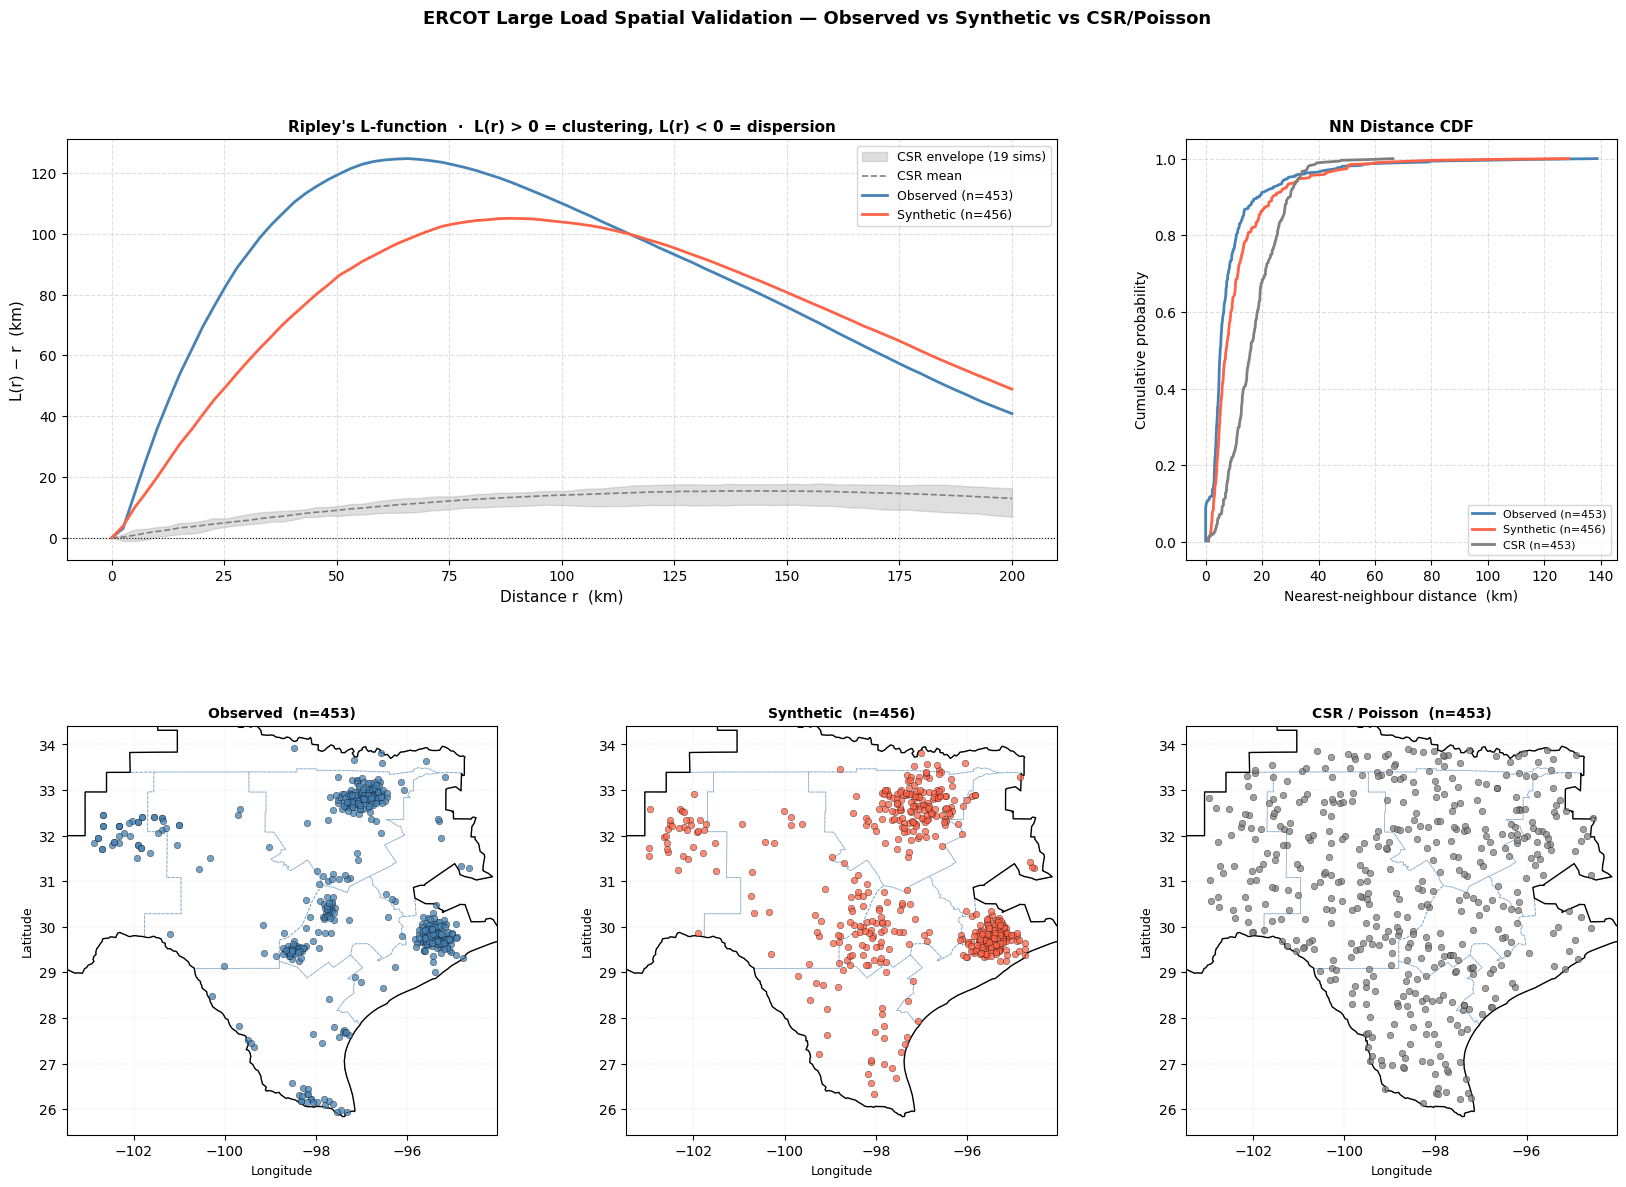

In [11]:
plot_spatial_validation(
    ref_loads_df      = ref_large_loads_gdf,
    synthetic_gdf     = synthetic_large_loads,
    boundary_polygon  = ercot_boundary,
    weather_zone_gdf  = ercot_zones_gdf,
    zone_col          = 'ERCOT_Clim',
    r_max_km          = 200,
    n_r               = 80,
    seed              = 42,
)

# Cell 11: Validation Plot — Synthetic vs Reference vs Poisson

Generates a 3-panel validation figure comparing the synthetic large loads against the reference case and a completely random (Poisson) baseline:

1. **Ripley's L(r) function** — measures spatial clustering at different distance scales. A good synthetic distribution should track the reference curve, not the flat Poisson line.
2. **Nearest-neighbor CDF** — cumulative distribution of distances to nearest neighbor. Synthetic should match reference; Poisson will be more spread out.
3. **Spatial map** — side-by-side scatter plots of reference, synthetic, and Poisson points on the ERCOT boundary.

This validates that the Thomas Cluster Process successfully reproduces the spatial clustering patterns of real large loads.

In [12]:
# Pre-processing
sgb.assign_load_q()
for g in sgb.gen_frags:
    for gu in g.units: gu.sbase = round(gu.pmax/.9, 1)
sgb.convert_gen_fuel()
sgb.assign_gen_qlims()
sgb.assign_gen_cost()

# Cell 12: Pre-Processing — Reactive Power, Generator Parameters, Costs

Prepares load and generator data for power flow modeling:

- **`sgb.assign_load_q()`** — assigns reactive power (Q) to each load based on power factor assumptions
- **Generator MVA base** — sets `sbase = pmax / 0.9` (90% power factor rating)
- **`sgb.convert_gen_fuel()`** — maps EIA fuel type strings to standard categories
- **`sgb.assign_gen_qlims()`** — sets generator reactive power limits based on capability curves
- **`sgb.assign_gen_cost()`** — assigns marginal cost curves by fuel type

In [13]:
# ── Create Areas (Weather Zones) and Zones (Counties) ─────────────────────────
# Brian: Created Zone assignment on top of the existing Area assignment code
sgb.create_areas()
sgb.create_zones()
lap("Areas and Zones created")

Created following area objects: 
<generator object create_areas.<locals>.<genexpr> at 0x0000026099205E40>
Created following zone objects: 
<generator object create_zones.<locals>.<genexpr> at 0x0000026099270940>
Areas and Zones created | 5.492466449737549 secs


# Cell 13: Create Areas

Creates Area objects in the grid workbench from the weather zone assignments already set on each load/gen fragment.

Unlike the EI version (which uses `area_split` tables), ERCOT areas are assigned directly via shapefile in the fragment creation cells, so this is just `sgb.create_areas()` with no additional logic.

In [14]:
# ── Clustering into Substations ───────────────────────────────────────────────
sgb.cluster_load_frags(18000)  # TODO: tune N for Texas — check with Dr. B
sgb.create_subs_old()

# Post-processing
for sub in sgb.syn_subs: sub.kvs = [100]

# Create power flow case with just substations
sgb.create_case_old()
lap("Substation clustering done")

Made neighbors 1.1188018321990967
Main clustering done 1.119297742843628
Made new neighbors 1.922670841217041
Substation clustering done | 2.2076823711395264 secs


# Cell 14: Clustering — Load Fragments into Substations

Groups nearby load fragments into substations using the SGB clustering algorithm.

- **`sgb.cluster_load_frags(N)`** — clusters load fragments so each substation serves roughly `N` people. The parameter `18000` is a placeholder — tune for Texas.
- **`sgb.create_subs_old()`** — creates `Sub` objects from the clusters, assigning loads and generators
- **`sgb.create_case_old()`** — builds the initial power flow case structure

**Expected output:** ~6,800–7,000 substations.

> **TODO:** Tune `N` parameter with Dr. B — affects how many substations are created.

In [15]:
# ── EHV Clustering (KMeans) ───────────────────────────────────────────────────
subs = sgb.wb.subs
sub_coords = [(s.longitude, s.latitude) for s in subs]

nc = 60  # TODO: tune for Texas — EI used 400, Texas is ~1/8 scale

class EHV_Cluster:
    def __init__(self):
        self.subs = []

clusters = [EHV_Cluster() for _ in range(nc)]
km = KMeans(n_clusters=nc, n_init=10).fit(sub_coords)
lap("KMeans clustering done")

for s, c in zip(subs, km.labels_):
    s.is_ehv = False
    s.cluster = c
    clusters[c].subs.append(s)

# Assign EHV identity based on cluster power content
for c in clusters:
    gen_p = sum(g.pmax for s in c.subs for g in s.gens)
    load_p = sum(l.p for s in c.subs for l in s.loads)
    p = gen_p + load_p
    c.n_ehv = min(10, int(round(p / 1500, 0)), len(c.subs))
    if p < 1200: c.n_ehv = 0
    c.subs.sort(key=lambda s: sum(-g.pmax for g in s.gens))
    i_ehv = 0
    for sub in c.subs:
        if i_ehv == c.n_ehv: break
        if sum(g.pmax for g in sub.gens) < 300: break
        i_ehv += 1
        sub.is_ehv = True
    while i_ehv < c.n_ehv:
        s = c.subs[int(random() * len(c.subs))]
        if s.is_ehv: continue
        i_ehv += 1
        s.is_ehv = True

n_ehv = sum(1 for s in subs if s.is_ehv)
print(f"EHV substations: {n_ehv} out of {len(subs)} total")

KMeans clustering done | 1.9165151119232178 secs
EHV substations: 132 out of 6870 total


# Cell 15: EHV Clustering (KMeans)

Identifies which substations should be **Extra-High Voltage (EHV)** — the backbone transmission nodes.

**Algorithm:**
1. KMeans groups all substations into `nc=60` geographic clusters
2. Within each cluster, calculates total generation + load MW
3. Assigns EHV status to substations with the most generation, proportional to cluster power
4. Clusters with < 1,200 MW total get no EHV substations
5. Remaining EHV slots are filled randomly within the cluster

**Expected output:** ~130–140 EHV substations out of ~6,800 total.

> **TODO:** Tune `nc` with Dr. B — EI used 400, Texas is roughly 1/8 scale so 50–70 is reasonable.

In [16]:
# ── kV Assignment + Load Scaling ──────────────────────────────────────────────

# Scale load by weather zone (region)
for s in subs:
    area_name = s.area.name
    if area_name in area_regions:
        region = area_regions[area_name]
        factor = region_load_factor.get(region, 1.0)
        for l in s.loads:
            l.ps *= factor / 2.1
            l.p = l.ps
            l.qs *= factor / 2.1
            l.q = l.qs

# Assign kV levels per substation using county (Zone) data, fallback to area
# Same logic as EI base code: s.kv_levels = [base]; if is_ehv: append(ehv)
for s in subs:
    # Try county-level kV first
    county = getattr(s, 'zone', None)
    county_name = county.name if county else None
    area_name = s.area.name

    if county_name and county_name in kv_zones:
        base_kv, ehv_kv = kv_zones[county_name]
    elif area_name in kv_areas:
        base_kv, ehv_kv = kv_areas[area_name]
    else:
        base_kv, ehv_kv = (138, 345)  # default fallback

    s.kv_levels = [base_kv]
    if s.is_ehv and ehv_kv > 0:
        s.kv_levels.append(ehv_kv)

# Add additional kv levels for cross-area connections
gg = geograph.GeoGraph(subs)
gg.Delaunay(1)
for s in subs:
    for s2 in gg.g.neighbors(s):
        kv2 = s2.kv_levels[0]
        if kv2 in s.kv_levels: continue
        if kv2 >= s.kv_levels[0]: continue
        if random() < 0.1:
            s.kv_levels.append(kv2)

ehv_subs = [s for s in subs if max(s.kv_levels) > 300]
gg = geograph.GeoGraph(ehv_subs)
gg.Delaunay(1)
for u, v, a in list(gg.g.edges(data=True)):
    if a["dist"] > 250:
        gg.g.remove_edge(u, v)
for s in ehv_subs:
    for s2 in gg.g.neighbors(s):
        kv2 = max(s2.kv_levels)
        if kv2 in s.kv_levels: continue
        if kv2 >= max(s.kv_levels): continue
        if random() < 0.2:
            s.kv_levels.append(kv2)

lap("kV levels assigned")

kV levels assigned | 0.7419595718383789 secs


# Cell 16: kV Assignment + Load Scaling

Two operations in one cell:

### Load Scaling
Scales load MW per weather zone using `region_load_factor` (currently uniform 1.0 — placeholder for Dr. B's values). The `/2.1` divisor adjusts the raw census population-based estimate to match realistic ERCOT system load levels.

### kV Level Assignment
Assigns voltage levels to each substation using the auto-extracted dictionaries:
1. **County-level** (`kv_zones`) — preferred, most granular
2. **Weather zone** (`kv_areas`) — fallback if county not in reference case
3. **Default** `(138, 345)` — last resort

EHV substations get a second kV level (e.g., 500 kV) appended. Non-EHV substations get only the base kV (e.g., 115 or 161).

### Cross-Area Connections
Uses Delaunay triangulation to identify neighboring substations across areas. With small probability (10–20%), adds the neighbor's kV level to enable cross-voltage connections in the transmission network.

In [ ]:
# ── Bus Creation + Gen Voltage Assignment ─────────────────────────────────────
busnum = len(sgb.wb.buses) + 1
for s in subs:
    b0 = s.buses[0]
    b0.nominal_kv = s.kv_levels[0]
    b0.name = s.name + f"_{b0.nominal_kv}"
    for kv in s.kv_levels[1:]:
        b = Bus(s, busnum)
        busnum += 1
        b.nominal_kv = kv
        b.name = s.name + f"_{b.nominal_kv}"

# Move large generators to highest voltage bus
for s in subs:
    behv = max(s.buses, key=lambda b: b.nominal_kv)
    if behv.nominal_kv < 300: continue
    gens = list(s.gens)
    gens.sort(key=lambda g: g.pmax)
    total_g = 0
    for g in gens:
        total_g += g.pmax
        if total_g >= 300:
            if len(behv.nodes) == 0:
                n = Node(behv, behv.number)
                n.name = behv.name
            else:
                n = behv.nodes[0]
            g.node = n

# ── Attach Synthetic Large Loads to Nearest Substations ───────────────────────
from sklearn.neighbors import BallTree

sub_lats  = np.array([s.latitude  for s in subs])
sub_lons  = np.array([s.longitude for s in subs])
sub_coords_rad = np.radians(np.column_stack([sub_lats, sub_lons]))
tree = BallTree(sub_coords_rad, metric='haversine')

ll_coords_rad = np.radians(
    synthetic_large_loads[['Latitude', 'Longitude']].values
)
_, nearest_idx = tree.query(ll_coords_rad, k=1)
nearest_idx = nearest_idx.flatten()

n_large_loads_attached = 0
for i, (_, ll_row) in enumerate(synthetic_large_loads.iterrows()):
    sub = subs[nearest_idx[i]]
    mw  = float(ll_row['AssignedMW'])

    # Attach to base kV bus (first bus) — large loads connect at transmission voltage
    b_base = sub.buses[0]
    if len(b_base.nodes) == 0:
        node = Node(b_base, b_base.number)
        node.name = b_base.name
    else:
        node = b_base.nodes[0]

    # Load ID must be 1-2 chars, unique per node — use numerical IDs
    existing_ids = {l.id for l in node.loads}
    load_id = None
    for num in range(1, 100):  # "1" through "99"
        candidate = str(num)
        if candidate not in existing_ids:
            load_id = candidate
            break
    if load_id is None:
        continue  # skip if all 99 IDs exhausted on this node

    ll = Load(node, load_id)
    ll.status = True
    ll.ps = ll.p = mw
    ll.qs = ll.q = mw * 0.33   # assume power factor ~0.95 -> Q ~ 0.33 * P
    n_large_loads_attached += 1

print(f"Attached {n_large_loads_attached} large loads (>= {LARGE_LOAD_MW} MW) to substations")
total_large_mw = synthetic_large_loads['AssignedMW'].sum()
print(f"Total large load MW: {total_large_mw:.0f} MW")

# ── Push cluster # and EIA 860 data to custom fields ──────────────────────────
sgb.wb.pw_instructions["sub.cluster"] = {"pwfield": ["CustomInteger:0"],
            "import_from_aux": "int"}
sgb.wb.pw_instructions["gen.eia860_plant"] = {"pwfield": ["CustomString:0"],
            "import_from_aux": "string"}
sgb.wb.pw_instructions["gen.eia860_generator"] = {"pwfield": ["CustomString:1"],
            "import_from_aux": "string"}

AUX_OUT = os.path.join(OUTPUT_DIR, "ERCOT_Subs.aux")
sgb.export_aux(AUX_OUT)

# ── Append Zone name records to AUX file ──────────────────────────────────────
# GridWorkbench doesn't have a Zone container, so we write the Zone data block
# directly. This gives PowerWorld the ZoneNum -> ZoneName mapping.
if hasattr(sgb, 'zone_dict') and sgb.zone_dict:
    zone_number_map = {name: idx for idx, name in enumerate(sorted(sgb.zone_dict.keys()), 1)}
    with open(AUX_OUT, "a") as f:
        f.write("\nDATA (Zone, [ZoneNum, ZoneName])\n{\n")
        for zone_name in sorted(sgb.zone_dict.keys()):
            znum = zone_number_map[zone_name]
            f.write(f'{znum} "{zone_name}"\n')
        f.write("}\n")
    print(f"Appended {len(zone_number_map)} zone names (counties) to AUX file")

lap(f"Exported ERCOT_Subs.aux → {AUX_OUT}")

# Cell 17: Bus Creation, Large Load Attachment, and Export

Final cell — builds the power flow model and exports it.

### Bus Creation
Creates `Bus` objects at each substation — one per kV level. Names follow the pattern `"SubName_kV"` (e.g., `"Harris-TX-1234_115"`, `"Harris-TX-1234_500"`).

### Generator Voltage Assignment
Moves large generators (cumulative > 300 MW) to the highest-voltage bus at their substation.

### Large Load Attachment
Uses a **BallTree** (haversine metric) to find the nearest substation for each synthetic large load. Creates a `Load` object with a single-letter ID (A–Z, a–z) on the base-kV bus. Assumes power factor ~0.95 (Q = 0.33 * P).

### Custom Fields + Export
Pushes cluster numbers and EIA 860 identifiers into PowerWorld custom fields, then exports the full case as `ERCOT_Subs.aux` to the `Output/` folder.

> **Output file:** `Texas_Synthetic_Grid/Output/ERCOT_Subs.aux`

# Change Log

## 2026-03-10 (Session 1)

### New Features
- **Replaced `sgb.read_csv()` with pandas `read_csv` / `read_excel`** for all input files. Fixes incompatibility with multi-sheet Excel files (EIA 860, ERCOT GIS Report).
- **Census Gazetteer + DP1 merged on GEOID** — previously iterated two separate lists with `zip()`, causing 0 load fragments. Now merged into a single `census_records` dict list.
- **EIA 860 xlsx headers fixed** — title row at index 0 was being read as headers. Changed to `header=1`.
- **NaN handling for pandas** — added `_val()` and `_str()` helper functions for generator fragment creation (pandas returns NaN where `sgb.read_csv()` returned empty strings).
- **Auto-extract kV configuration from PowerWorld reference case** — no more manual kV dictionaries. Reads substations from `.pwb` and builds `kv_zones` (county), `kv_areas` (weather zone), `zone_regions` mappings automatically. Uses `(base_kv, ehv_kv)` tuple format matching EI base code.
- **Output path override** — added `OUTPUT_DIR` and set `sgb.output_folder = OUTPUT_DIR` so exports go to `Texas_Synthetic_Grid/Output/` instead of the config file's `root` path.
- **Large Load Synthetic Allocation** — new module `large_load_allocation.py` implementing Thomas Cluster Process:
  - Extracts reference large loads (>= 75 MW) from PowerWorld case via 3-step join (Load → Bus → Substation lat/lon)
  - Builds per-weather-zone area stats (count, centroid, spread)
  - Fits Thomas Cluster Process parameters (kappa, sigma) using Ripley's K/L function + Nelder-Mead optimization
  - Generates synthetic locations via Poisson offspring with Gaussian scatter
  - Assigns MW via per-zone lognormal distribution fit
- **Validation plot** — 3-panel figure comparing synthetic vs reference vs Poisson (Ripley's L, nearest-neighbor CDF, spatial map)
- **Large load attachment to substations** — BallTree nearest-substation lookup, creates `Load` objects on base-kV bus
- **Zone (county) support** — added `sgb.create_zones()` method in `sub_planning.py`. Appends `DATA (Zone, [ZoneNum, ZoneName])` block to AUX file so PowerWorld shows county names.
- **Markdown documentation** — added explanation cells before every code cell + configuration guide + data source download links

### Bug Fixes
- **0 load fragments** — root cause: `sgb.read_csv()` + misaligned `zip()` of national Gazetteer vs TX-only DP1. Fixed by pandas merge on GEOID.
- **KeyError 'Plant Code'** — EIA xlsx `header=0` read the title row. Fixed to `header=1`.
- **0 large loads extracted** — first attempt queried Bus for Latitude/Longitude (returns 0 for buses). Fixed to 3-step join through Substation.
- **Module caching** — changes to `large_load_allocation.py` not reflected. Fixed with `importlib.reload()`.
- **Load ID 'LL1' too long** — gridworkbench requires 1-2 char IDs. Changed to numerical IDs ("1" through "99").
- **OSError double path in export_aux** — `sgb.export_aux(full_path)` prepended `output_folder` again. Fixed by overriding `sgb.output_folder = OUTPUT_DIR` and updating `export_aux` to not prepend.
- **Zone not showing in PowerWorld** — gridworkbench `export_aux` has no Zone container. Fixed by appending Zone data block directly to AUX file after export.

### Parameters (Current Values — Tuning Needed)
| Parameter | Value | Notes |
|-----------|-------|-------|
| `cluster_load_frags(N)` | 18000 | Placeholder — ask Dr. B |
| `nc` (EHV KMeans) | 60 | EI used 400; Texas ~1/8 scale |
| `region_load_factor` | 1.0 (all zones) | Placeholder — need per-zone factors |
| Load scaling divisor | /2.1 | Census pop → system MW |
| Large load threshold | >= 75 MW | ERCOT design criterion |
| `fit_thomas` | True | Full Thomas process fitting |
| `seed` | 42 | Reproducibility |

### Output Summary (This Run)
- 6,288 load fragments
- 628 gen fragments (1,551 units, 147,977 MW)
- 6,870 substations (132 EHV)
- 456 synthetic large loads (62,782 MW)
- 200 county zones appended to AUX
- Export: `Texas_Synthetic_Grid/Output/ERCOT_Subs.aux`